In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Legge il CSV
df = pd.read_csv("MCMC_3param_risultati.csv")

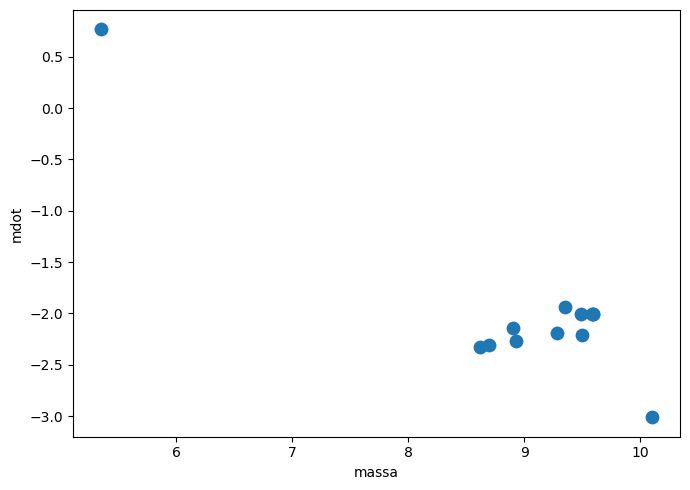

In [55]:
plt.figure(figsize=(7,5))

plt.scatter(np.log10(df["massa"]), np.log10(df["mdot"]), s=80)

# Assi
plt.xlabel("massa")
plt.ylabel("mdot")

plt.tight_layout()
plt.show()

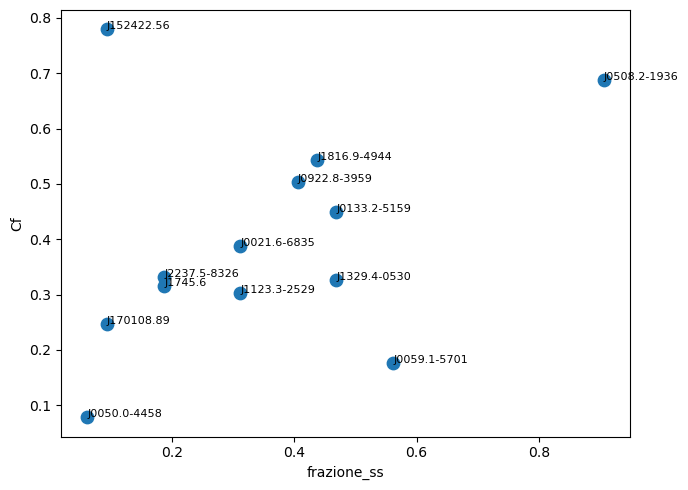

In [56]:
plt.figure(figsize=(7,5))

plt.scatter(df["frazione_ss"], df["cf"], s=80)

# Etichette dei punti
for i, row in df.iterrows():
    plt.text(row["frazione_ss"], row["cf"], row["nome_blazar"], fontsize=8)

# Assi
plt.xlabel("frazione_ss")
plt.ylabel("Cf")

plt.tight_layout()
plt.show()# Plot


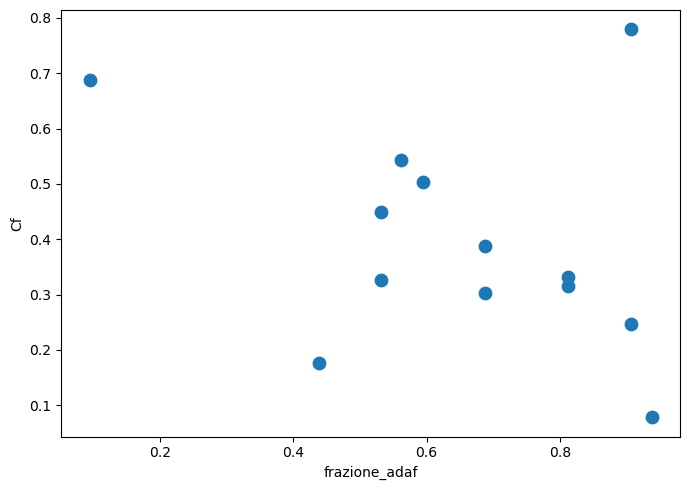

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(df["frazione_adaf"], df["cf"], s=80)

# Assi
plt.xlabel("frazione_adaf")
plt.ylabel("Cf")

plt.tight_layout()
plt.show()

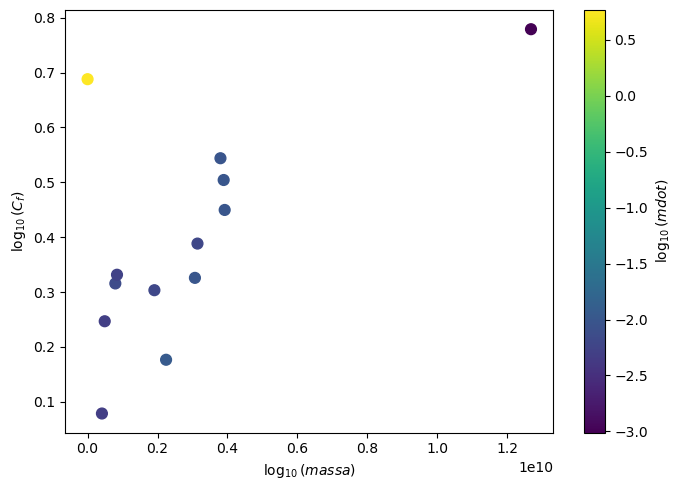

In [58]:
plt.figure(figsize=(7,5))

# Scatter colorato con la massa
sc = plt.scatter(
    #np.log10(df["massa"]),
    df["massa"],
    df["cf"],
    c=np.log10(df["mdot"]),   
    s=60
)

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label(r'$\log_{10}(mdot)$')

"""
# Labels punti
for i, row in df.iterrows():
    plt.text(
        np.log10(row["massa"]),
        np.log10(row["cf"]),
        row["nome_blazar"],
        fontsize=8
    )
"""

# Assi
plt.xlabel(r'$\log_{10}(massa)$')
plt.ylabel(r'$\log_{10}(C_f)$')

plt.tight_layout()
plt.show()

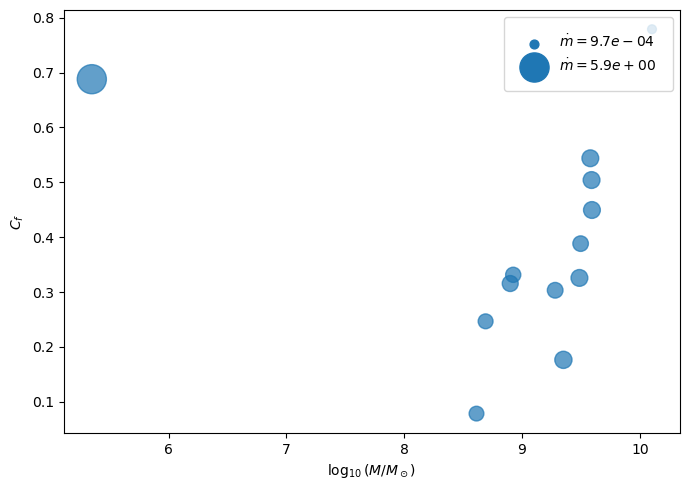

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dimensione punti da mdot
log_mdot = np.log10(df["mdot"])
sizes = 40 + 400 * (
    (log_mdot - log_mdot.min()) /
    (log_mdot.max() - log_mdot.min())
)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(
    np.log10(df["massa"]),
    df["cf"],
    s=sizes,
    alpha=0.7
)

"""
for i, row in df.iterrows():
    plt.text(
        np.log10(row["massa"]),
        row["cf"],
        row["nome_blazar"],
        fontsize=8
    )
"""

# Legenda dimensioni
mdot_min = df["mdot"].min()
mdot_max = df["mdot"].max()

size_min = sizes.min()
size_max = sizes.max()

legend1 = plt.scatter(
    [], [],
    s=size_min,
    color="C0",
    label=fr'$\dot m = {mdot_min:.1e}$'
)

legend2 = plt.scatter(
    [], [],
    s=size_max,
    color="C0",
    label=fr'$\dot m = {mdot_max:.1e}$'
)

plt.legend(handles=[legend1, legend2],loc="upper right",borderpad=1.2)


plt.xlabel(r'$\log_{10}(M/M_\odot)$')
plt.ylabel(r'$C_f$')

plt.tight_layout()
plt.show()

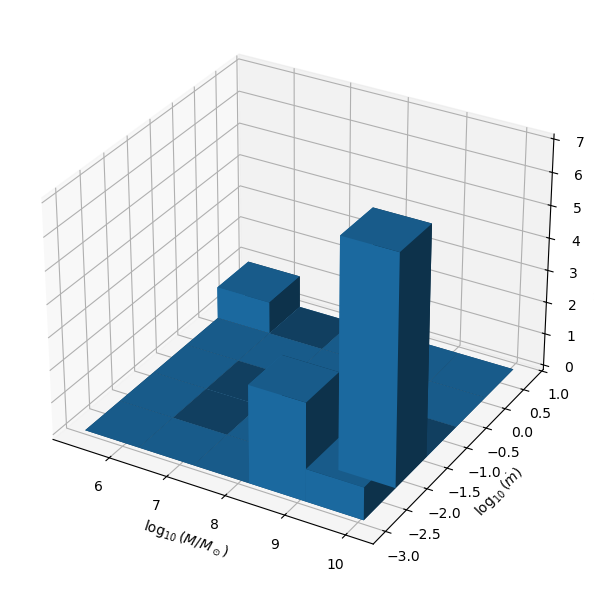

In [65]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

# =========================
# Dati
# =========================

x = np.log10(df["massa"])
y = np.log10(df["mdot"])

# =========================
# Istogramma 2D
# =========================

hist, xedges, yedges = np.histogram2d(
    x,
    y,
    bins=5
)

# coordinate bin
xpos, ypos = np.meshgrid(
    xedges[:-1],
    yedges[:-1],
    indexing="ij"
)

xpos = xpos.ravel()
ypos = ypos.ravel()

zpos = np.zeros_like(xpos)

dx = (xedges[1] - xedges[0]) * np.ones_like(zpos)
dy = (yedges[1] - yedges[0]) * np.ones_like(zpos)

dz = hist.ravel()

# =========================
# Plot 3D
# =========================

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.bar3d(
    xpos,
    ypos,
    zpos,
    dx,
    dy,
    dz,
    shade=True
)

# =========================
# Assi
# =========================

ax.set_xlabel(r'$\log_{10}(M/M_\odot)$')
ax.set_ylabel(r'$\log_{10}(\dot m)$')
ax.set_zlabel('Numero oggetti')

plt.tight_layout()
plt.show()